In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
file_size_df = pd.read_csv("results/reports/file_sizes.csv")
file_size_df.sample(10)

,SRA_Number,File_Name,File_Path,Process_Name,Read_Label,Size_Byte,Size_KB,Size_MB
166,ERR322697,ERR322697_2.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Repair Read Output,Read_2,24798139,24216.93,23.65
197,ERR322856,ERR322856.unclassified_2.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Contamination Output,Read_2,1109789,1083.78,1.06
1,ERR322565,ERR322565_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Initial Input Files,Read_1,24845724,24263.40,23.69
171,ERR322378,ERR322378_2.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Repair Read Output,Read_2,13165283,12856.72,12.56
164,ERR322856,ERR322856_2.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Repair Read Output,Read_2,30303866,29593.62,28.90
109,ERR322944,ERR322944_2.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Repair Read Output,Read_2,27140961,26504.84,25.88
188,ERR322697,ERR322697_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Initial Input Files,Read_1,28970886,28291.88,27.63
23,ERR3908889,ERR3908889_2_val_2.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_2,39547184,38620.30,37.72
113,ERR322697,ERR322697_1_val_1.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_1,4390474,4287.57,4.19
97,ERR322567,ERR322567_2_val_2.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_2,0,0.00,0.00


In [30]:
process_order = [
    "Initial Input Files",
    "Repair Read Output",
    "Quality Control Output",
    "Contamination Output",
    "Mapping Output",
]
# Create a ranking dictionary
order_map = {name: i for i, name in enumerate(process_order)}

# Add a temporary sort key column
file_size_df["_process_order"] = file_size_df["Process_Name"].map(order_map)

ordered_file_size_df = file_size_df.sort_values(
    by=["SRA_Number", "Read_Label", "_process_order"], ascending=[True, True, True]
).drop(columns=["_process_order"])
ordered_file_size_df

,SRA_Number,File_Name,File_Path,Process_Name,Read_Label,Size_Byte,Size_KB,Size_MB
8,ERR322376,ERR322376_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Initial Input Files,Read_1,21907036,21393.59,20.89
167,ERR322376,ERR322376_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Repair Read Output,Read_1,18775382,18335.33,17.91
18,ERR322376,ERR322376_1_val_1.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_1,3001449,2931.10,2.86
16,ERR322376,ERR322376.unclassified_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Contamination Output,Read_1,2740009,2675.79,2.61
129,ERR322376,ERR322376.filtered.A.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Mapping Output,Read_1,2740009,2675.79,2.61
...,...,...,...,...,...,...,...,...
198,SRR11888866,SRR11888866.filtered.A.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Mapping Output,Read_1,57994,56.63,0.06
52,SRR11888866,SRR11888866_2.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Initial Input Files,Read_2,38587104,37682.72,36.80
125,SRR11888866,SRR11888866_2_val_2.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_2,13545162,13227.70,12.92
199,SRR11888866,SRR11888866.unclassified_2.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Contamination Output,Read_2,12158147,11873.19,11.59


In [31]:
ordered_file_size_df["diff"] = (
    ordered_file_size_df.groupby(["SRA_Number", "Read_Label"])["Size_MB"]
    .diff(-1)
    .fillna(ordered_file_size_df["Size_MB"])
)
ordered_file_size_df["percentage_diff"] = (
    (
        ordered_file_size_df["diff"]
        / ordered_file_size_df.groupby(["SRA_Number", "Read_Label"])["diff"].transform(
            "sum"
        )
    )
    * 100
).round(2)

In [32]:
ordered_file_size_df

,SRA_Number,File_Name,File_Path,Process_Name,Read_Label,Size_Byte,Size_KB,Size_MB,diff,percentage_diff
8,ERR322376,ERR322376_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Initial Input Files,Read_1,21907036,21393.59,20.89,2.98,14.27
167,ERR322376,ERR322376_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Repair Read Output,Read_1,18775382,18335.33,17.91,15.05,72.04
18,ERR322376,ERR322376_1_val_1.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_1,3001449,2931.10,2.86,0.25,1.20
16,ERR322376,ERR322376.unclassified_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Contamination Output,Read_1,2740009,2675.79,2.61,0.00,0.00
129,ERR322376,ERR322376.filtered.A.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Mapping Output,Read_1,2740009,2675.79,2.61,2.61,12.49
...,...,...,...,...,...,...,...,...,...,...
198,SRR11888866,SRR11888866.filtered.A.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Mapping Output,Read_1,57994,56.63,0.06,0.06,0.16
52,SRR11888866,SRR11888866_2.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Initial Input Files,Read_2,38587104,37682.72,36.80,23.88,64.89
125,SRR11888866,SRR11888866_2_val_2.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_2,13545162,13227.70,12.92,1.33,3.61
199,SRR11888866,SRR11888866.unclassified_2.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Contamination Output,Read_2,12158147,11873.19,11.59,11.53,31.33


In [33]:
pivot_df = ordered_file_size_df.pivot(
    index=["SRA_Number", "Read_Label"], columns="Process_Name", values="percentage_diff"
)
pivot_df = pivot_df[process_order]
pivot_df = pivot_df.rename(columns={
    "Initial Input Files": "Size reduced after repair process",
    "Repair Read Output": "size reduced after Quality Control",
    "Quality Control Output": "size reduced after Contamination Removal",
    "Contamination Output": "size reduced after Mapping",
    "Mapping Output": "Final remaining size for reassembly",
})

In [34]:
pivot_df = pivot_df.reset_index()
pivot_df

Process_Name,SRA_Number,Read_Label,Size reduced after repair process,size reduced after Quality Control,size reduced after Contamination Removal,size reduced after Mapping,Final remaining size for reassembly
0,ERR322376,Read_1,14.27,72.04,1.20,0.00,12.49
1,ERR322376,Read_2,14.14,72.15,1.20,0.00,12.51
2,ERR322378,Read_1,14.27,71.88,1.23,0.00,12.63
3,ERR322378,Read_2,14.15,71.98,1.23,0.00,12.65
4,ERR322401,Read_1,14.63,85.37,0.00,NaN,NaN
5,ERR322401,Read_2,14.45,85.55,0.00,NaN,NaN
6,ERR322446,Read_1,14.41,85.59,0.00,NaN,NaN
7,ERR322446,Read_2,14.25,85.75,0.00,NaN,NaN
8,ERR322460,Read_1,32.73,67.27,0.00,NaN,NaN
9,ERR322460,Read_2,14.60,85.40,0.00,NaN,NaN


<Figure size 1200x600 with 0 Axes>

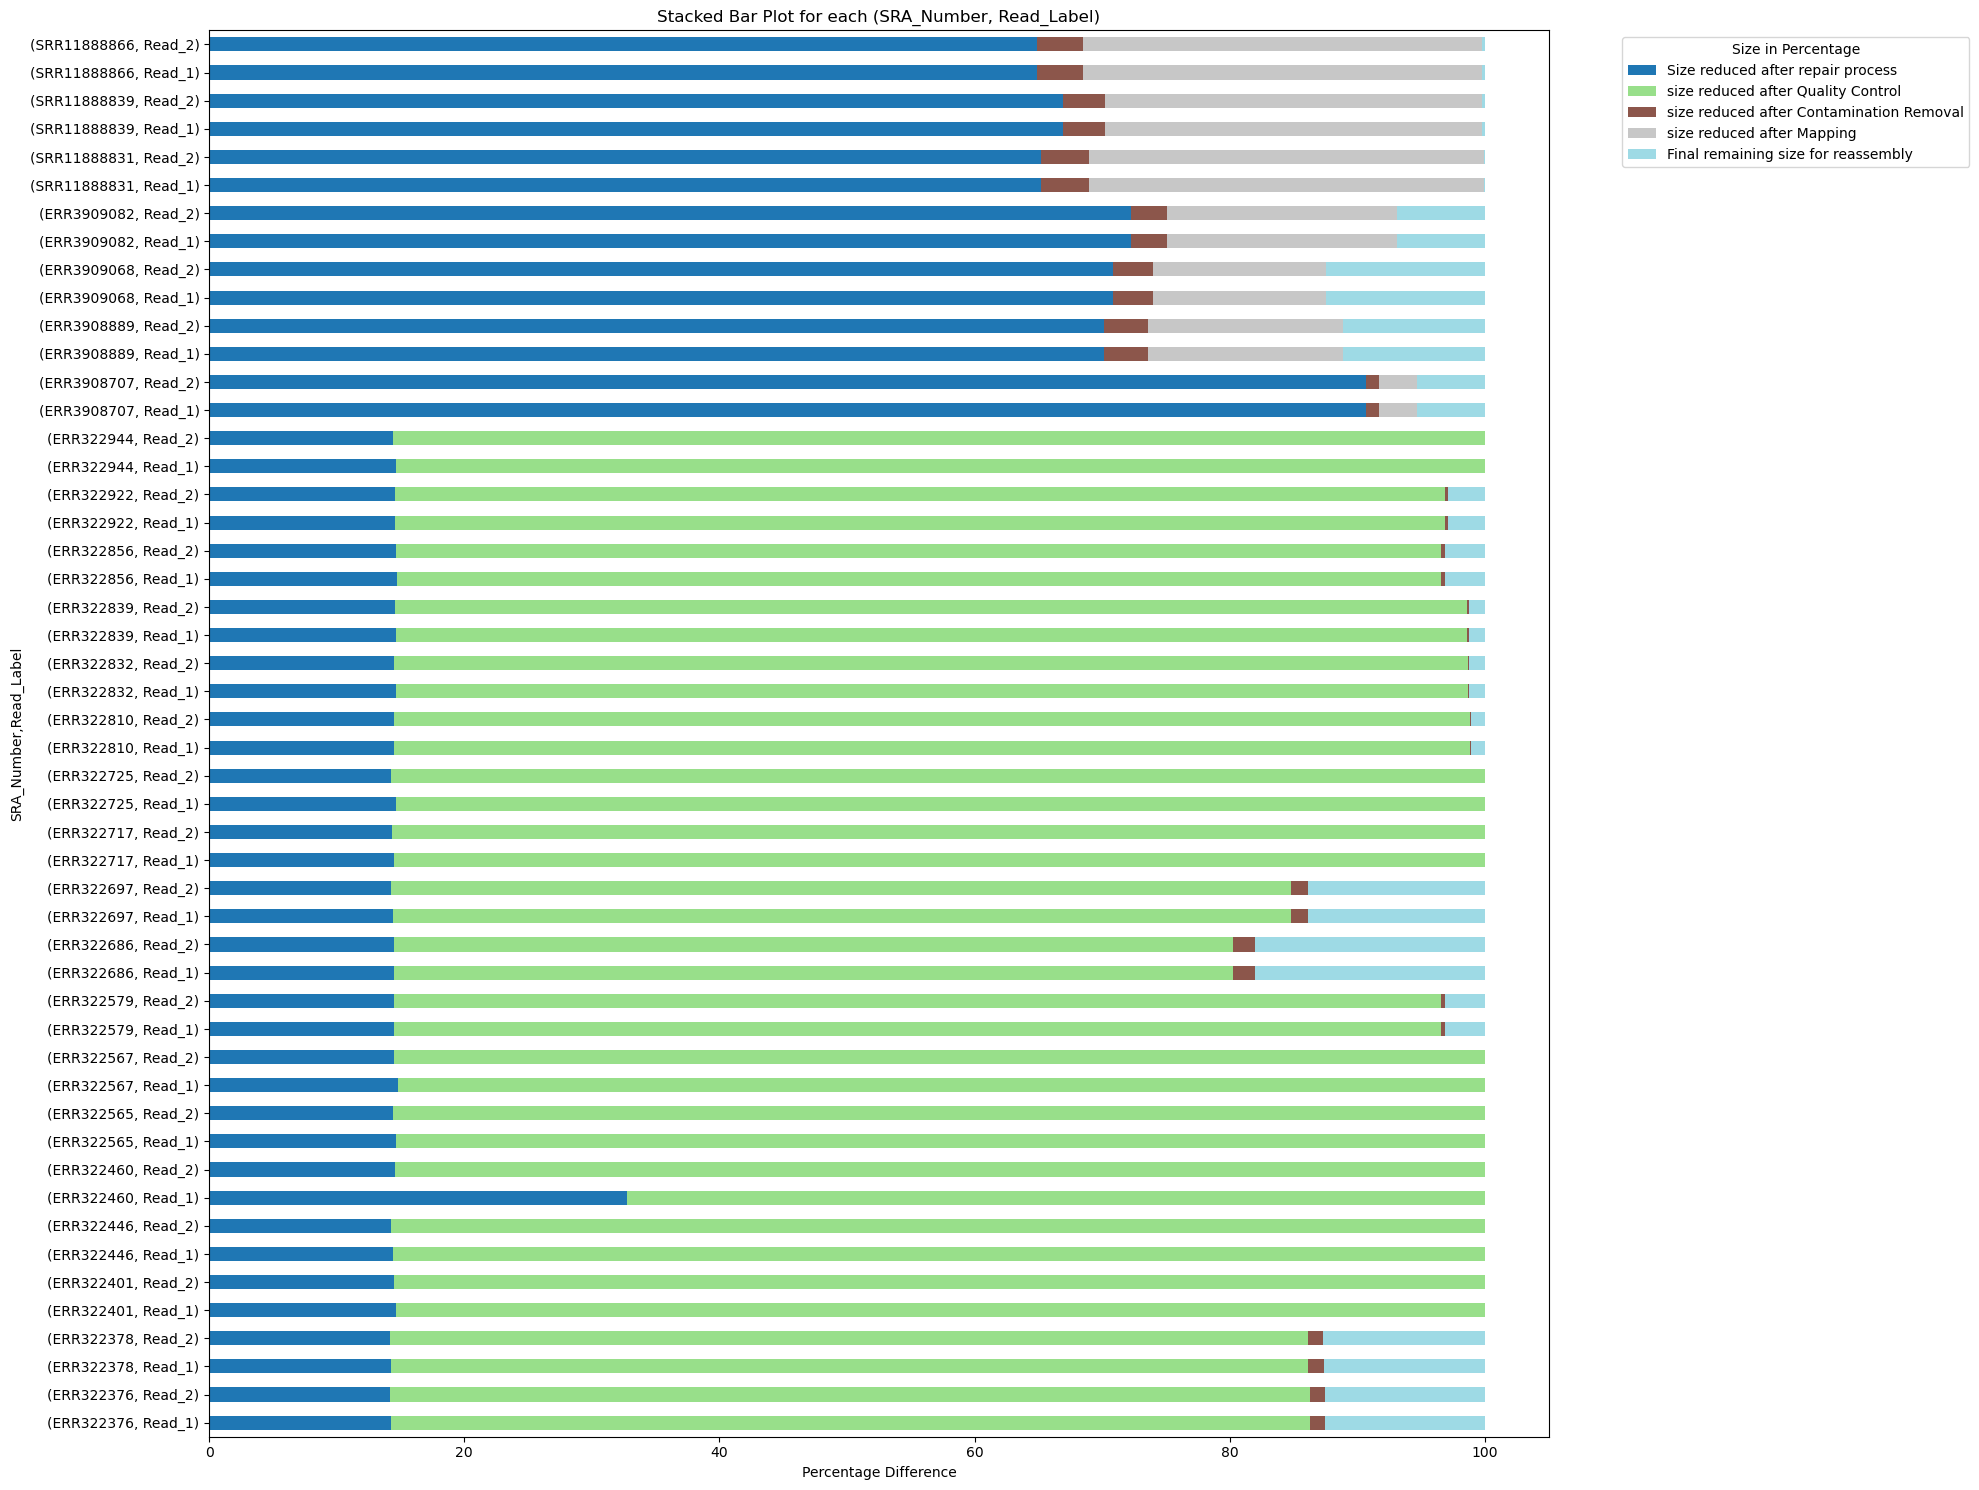

In [47]:
import matplotlib.pyplot as plt

# Set plot size
plt.figure(figsize=(12, 6))

# Plot stacked bar chart
pivot_df.set_index(["SRA_Number", "Read_Label"]).plot(
    kind="barh",
    stacked=True,
    figsize=(20, 15),
    colormap="tab20"
)

plt.xlabel("Percentage Difference")
plt.title("Stacked Bar Plot for each (SRA_Number, Read_Label)")
# plt.xticks(rotation=45, ha="right")
plt.legend(title="Size in Percentage", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=ordered_file_size_df,
    x="SRA_Number",
    y="percentage_diff",
    hue="Process_Name",
    stacked=True,
)